## Useful functions and libraries

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from data import SwaptionDataset
from torch.utils.data import DataLoader, Subset
from perceval import *
from merlin import QuantumLayer
import numpy as np

In [92]:
TENORS_LIST    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30]
MATURITIES_LIST = [0.083, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]

MAT_LABELS = ["0M","3M","6M","9M","1Y","18M","2Y","3Y","4Y","5Y","7Y","10Y","15Y","20Y","25Y","30Y"]
TEN_LABELS = [f"{t}Y" for t in TENORS_LIST]

def plot_surface_comparison(model, dataset, sample_idx=-1):
    """Compare real vs predicted swaption surface for one sample day."""
    model.eval()

    idx = sample_idx if sample_idx >= 0 else len(dataset) + sample_idx
    x, y_real = dataset[idx]

    with torch.no_grad():
        y_pred = model(x.float().unsqueeze(0)).squeeze(0).numpy()
    y_real = y_real.numpy()

    # Reshape [224] → [14 tenors, 16 maturities]  (Tenor on Y-axis, Maturity on X-axis)
    # Column ordering in dataset: maturity-major → reshape to [16 mat, 14 ten], then transpose
    real  = y_real.reshape(len(MATURITIES_LIST), len(TENORS_LIST)).T   # [14, 16]
    pred  = y_pred.reshape(len(MATURITIES_LIST), len(TENORS_LIST)).T
    error = pred - real

    vmin, vmax = min(real.min(), pred.min()), max(real.max(), pred.max())
    absmax = np.abs(error).max()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    panels = [
        (real,  "Real Surface",       "RdYlGn_r", dict(vmin=vmin, vmax=vmax)),
        (pred,  "Predicted Surface",  "RdYlGn_r", dict(vmin=vmin, vmax=vmax)),
        (error, "Error (Pred − Real)","RdBu_r",   dict(vmin=-absmax, vmax=absmax)),
    ]

    for ax, (data, title, cmap, kwargs) in zip(axes, panels):
        im = ax.imshow(data, aspect='auto', cmap=cmap, origin='upper',
                       interpolation='bicubic', **kwargs)
        ax.set_xticks(range(len(MATURITIES_LIST)))
        ax.set_xticklabels(MAT_LABELS, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(TENORS_LIST)))
        ax.set_yticklabels(TEN_LABELS, fontsize=8)
        ax.set_xlabel("Maturity")
        ax.set_ylabel("Tenor")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    date = dataset.dates.iloc[idx + dataset.lookback].date()
    plt.suptitle(f"Swaption Surface — {date}", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/surface_comparison.png", bbox_inches='tight')
    plt.show()

    mae = np.abs(error).mean()
    print(f"MAE  : {mae:.6f}")
    worst = np.unravel_index(np.abs(error).argmax(), error.shape)
    print(f"Max |error| : {np.abs(error).max():.6f}  at Tenor={TEN_LABELS[worst[0]]}, Maturity={MAT_LABELS[worst[1]]}")


def get_predictions(model, subset):
    model.eval()
    all_real, all_pred = [], []
    dl = DataLoader(subset, batch_size=64, shuffle=False)
    with torch.no_grad():
        for x, y in dl:
            all_real.append(y.numpy())
            all_pred.append(model(x.float()).numpy())
    return np.concatenate(all_real), np.concatenate(all_pred)


def print_metrics(real, pred, name):
    mae  = np.abs(real - pred).mean()
    rmse = np.sqrt(((real - pred) ** 2).mean())
    r2   = 1 - np.sum((real - pred) ** 2) / np.sum((real - real.mean()) ** 2)
    mape = (np.abs((real - pred) / (real + 1e-8))).mean() * 100
    print(f"  {name:<28s}  MAE={mae:.5f}  RMSE={rmse:.5f}  R²={r2:.4f}  MAPE={mape:.2f}%")

def plot_surface_slide(data, title, ax, vmin, vmax, cmap="RdYlGn_r"):
    """Single panel in slide-5 style: smooth gradient, clean axes."""
    im = ax.imshow(data, aspect="auto", cmap=cmap, origin="upper",
                   vmin=vmin, vmax=vmax, interpolation="bicubic")
    # Sparse tick labels to match the slide style
    x_ticks = [0, 2, 4, 6, 9, 11, 14, 15]        # 0M 6M 1Y 2Y 4Y 7Y 15Y 25Y
    y_ticks = [0, 2, 4, 6, 8, 10, 12, 13]         # 1Y 3Y 5Y 7Y 9Y 15Y 25Y 30Y
    x_labels = ["0M","6M","1Y","2Y","4Y","7Y","15Y","25Y"]
    y_labels = ["1Y","3Y","5Y","7Y","9Y","15Y","25Y","30Y"]
    ax.set_xticks(x_ticks); ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_yticks(y_ticks); ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel("Maturity", fontsize=10)
    ax.set_ylabel("Tenor",    fontsize=10)
    ax.set_title(title, fontsize=12, pad=8)
    ax.tick_params(length=0)           # no tick marks, just labels (slide style)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return im


# Swaption Surface Predictor — Hybrid Quantum-Classical Model

Predicts **224 swaption prices one day ahead** using a hybrid pipeline:  
`LSTM → classical compression → photonic quantum circuit → linear regressor`

| | |
|---|---|
| **Input** | `[B, 20, 225]` — 20 days × (time-delta + 224 prices) |
| **Output** | `[B, 224]` — next-day swaption prices (14 tenors × 16 maturities) |
| **Dataset** | 494 calendar rows → 474 usable samples (lookback = 20, horizon = 1) |
| **Split** | Train: samples 0–459 (460 days) · Validation: samples 460–473 (14 days) |

## 1. Data Loading

`SwaptionDataset` (from `data/data.py`) reads `data/train.xlsx` and returns sliding windows.  
Each sample `(x, y)`: `x = [20, 225]` where `x[:, 0]` is the time-delta in days and `x[:, 1:]` are the 224 prices; `y = [224]` is the next day's prices.  
The dataset is split **chronologically** — no shuffling — to avoid look-ahead bias.

In [73]:
dataset = SwaptionDataset()
n = len(dataset)
train_ds = Subset(dataset, range(0, 460))
val_ds  = Subset(dataset, range(460, n))

device = "cuda" if torch.cuda.is_available() else "cpu"

loader = DataLoader(train_ds, batch_size=8, shuffle=True) 
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

## 2. Model Architecture — SwaptionPredictor

A three-stage hybrid model:

1. **LSTM** (`input=225, hidden=64, 1 layer`) — processes the full 20-day window; only the last hidden state `h_n` is kept.  
2. **Feature compression** (`Linear 64→8`) + sigmoid×π — projects to [0, π], the valid encoding range for the quantum circuit's phase-shift gates.  
3. **Photonic quantum circuit** (8 modes, 2 photons) — two trainable `GenericInterferometer` blocks (MZI mesh) with 8 input phase-shift gates encoding the classical features. Fock-space simulation; output size = 36.  
4. **Regressor** (`Linear 36→224`) — maps quantum measurement probabilities to the 224 swaption prices.

In [74]:
# LSTM -> Classical compression -> Quantum circuit -> Regressor
class SwaptionPredictor(nn.Module):
    def __init__(self):
        super(SwaptionPredictor, self).__init__()

        self.lstm = nn.LSTM(
            input_size=225,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.feature_reduction = nn.Linear(64, 8)

        n_modes   = 8
        n_photons = 2   

        input_params = [P(f"x{i}") for i in range(n_modes)]

        circuit = Circuit(n_modes)

        interferometer1 = GenericInterferometer(
            n_modes,
            catalog["mzi phase first"].generate
        )
        circuit.add(0, interferometer1)

        for i in range(n_modes):
            circuit.add(i, PS(input_params[i]))

        interferometer2 = GenericInterferometer(
            n_modes,
            catalog["mzi phase first"].generate,
        )
        for p in interferometer2.get_parameters():
            p.name = "layer2_" + p.name

        circuit.add(0, interferometer2)

        all_params  = circuit.get_parameters()
        train_params = [p.name for p in all_params if not p.name.startswith("x")]

        # Build input state: n_photons ones followed by zeros
        photon_state = [1] * n_photons + [0] * (n_modes - n_photons)

        self.quantum_layer = QuantumLayer(
            circuit=circuit,
            input_state=BasicState(photon_state),
            input_parameters=[f"x{i}" for i in range(n_modes)],
            trainable_parameters=train_params,
            computation_space="Fock"
        )

        self.regressor = nn.Linear(self.quantum_layer.output_size, 224)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        x = hn.squeeze(0)
        x = self.feature_reduction(x)
        x = torch.sigmoid(x) * torch.pi
        x = self.quantum_layer(x)
        x = self.regressor(x)
        return x

In [75]:
model = SwaptionPredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

### Quantum Circuit Diagram

`pdisplay()` renders the full Perceval circuit inline as SVG: MZI meshes (interferometers) + 8 phase-shift encoding gates.


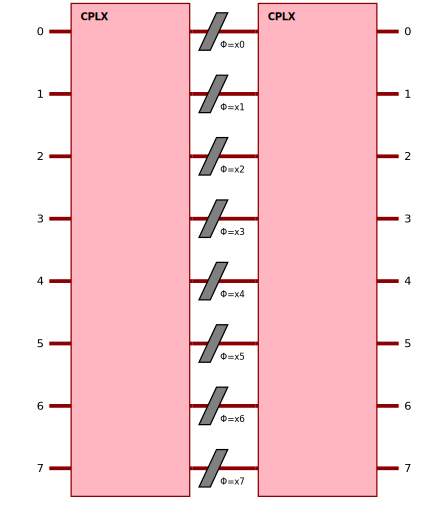

In [98]:
circuit = Circuit(8)
input_params = [P(f"x{i}") for i in range(8)]

interferometer1 = GenericInterferometer(
    8,
    catalog["mzi phase first"].generate
)
circuit.add(0, interferometer1)

for i in range(8):
    circuit.add(i, PS(input_params[i]))

interferometer2 = GenericInterferometer(
    8,
    catalog["mzi phase first"].generate,
)
for p in interferometer2.get_parameters():
    p.name = "layer2_" + p.name

circuit.add(0, interferometer2)

pdisplay(circuit)

## 3. Training

- **Loss**: MSE  
- **Optimiser**: Adam (lr = 1×10⁻³)  
- **Epochs**: 200, batch size 8, training set shuffled each epoch  

After training, `validation(tenor, maturity)` runs the full dataset through the frozen model and returns `(model_prices, real_prices)` for any chosen grid cell — useful for quick visual inspection.

In [76]:
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in loader:
        inputs, targets = inputs.float(), targets.float()
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # avg_loss = running_loss / len(loader)
    loss_history.append(running_loss)

    if (epoch + 1) % 20 == 0: 
        print(f"Epoch [{epoch+1}/{num_epochs}] | MSE Loss: {running_loss:.8f}")

print("Training Complete!")

# Switch to evaluation mode
model.eval()

MATURITIES = [0.083, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]

def validation(tenor, maturity):
    complete_loader = DataLoader(dataset, batch_size=256, shuffle=False)

    model.eval()

    tenor_idx = dataset.tenors.index(tenor)
    maturity_idx = MATURITIES.index(round(maturity, 3))
    col = maturity_idx * len(dataset.tenors) + tenor_idx

    real_prices = []
    model_prices = []

    with torch.no_grad():
        for X, y in complete_loader:

            X = X.to(device)
            y = y.to(device)

            preds = model(X)

            real_prices.extend(y[:, col].cpu().numpy())
            model_prices.extend(preds[:, col].cpu().numpy())

    return model_prices, real_prices

Epoch [20/200] | MSE Loss: 0.00694318
Epoch [40/200] | MSE Loss: 0.00303051
Epoch [60/200] | MSE Loss: 0.00198866
Epoch [80/200] | MSE Loss: 0.00178039
Epoch [100/200] | MSE Loss: 0.00192694
Epoch [120/200] | MSE Loss: 0.00177679
Epoch [140/200] | MSE Loss: 0.00155092
Epoch [160/200] | MSE Loss: 0.00119233
Epoch [180/200] | MSE Loss: 0.00112403
Epoch [200/200] | MSE Loss: 0.00131886
Training Complete!


### Quick Check — Single Grid Cell

Visual sanity check of real vs. predicted prices across the full dataset for **Tenor 1Y / Maturity 3Y**. The vertical black line marks the train/validation split at sample 460.

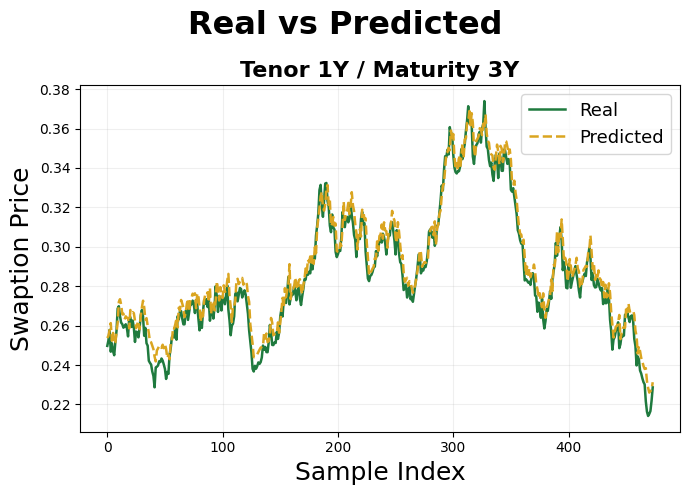

In [80]:
model_prices, real_prices = validation(tenor=1, maturity=3)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")

#ax.axvline(x=460, color="black", linewidth=2, label="Train / Val split")

ax.plot(real_prices,  color="#1f7a3e", linewidth=1.8, label="Real")
ax.plot(model_prices, color="goldenrod", linewidth=1.8, linestyle="--", label="Predicted")

ax.set_title("Tenor 1Y / Maturity 3Y", fontsize=16, fontweight="bold")
ax.set_xlabel("Sample Index", fontsize=18)
ax.set_ylabel("Swaption Price", fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.2)

fig.suptitle("Real vs Predicted", fontsize=23, fontweight="bold")
plt.tight_layout()
plt.show()

# Get one batch of real data
val_inputs, val_targets = next(iter(val_loader))
train_inputs, train_targets = next(iter(loader))

# Get the model's guess
with torch.no_grad():
    val_predictions = model(val_inputs.float())
    train_predictions = model(train_inputs.float())

### Training Loss Curve

MSE loss summed over all batches per epoch, plotted on a log scale. A monotonically decreasing curve with no spikes indicates stable convergence.

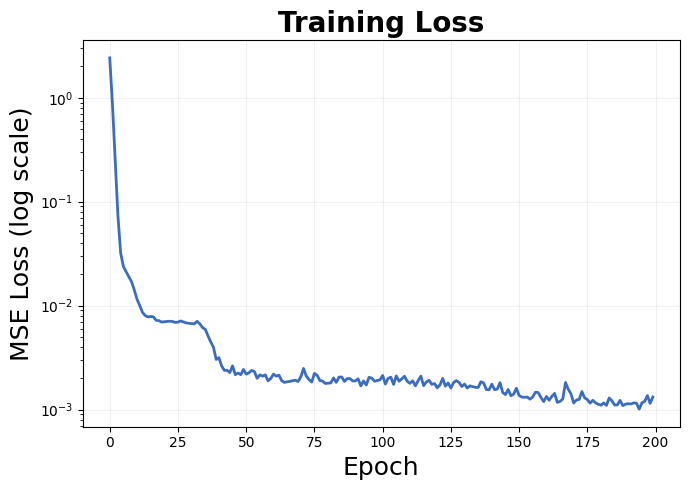

In [84]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")

ax.plot(loss_history, color="#3a6dbf", linewidth=2.0)
ax.set_yscale("log")

ax.set_title("Training Loss", fontsize=20, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=18)
ax.set_ylabel("MSE Loss (log scale)", fontsize=18)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Single-Day Surface Snapshot

`plot_surface_comparison` evaluates the model on one sample (here `sample_idx=50`, a training day) and displays three panels side by side: real surface, predicted surface, and signed error — all on a consistent colour scale.

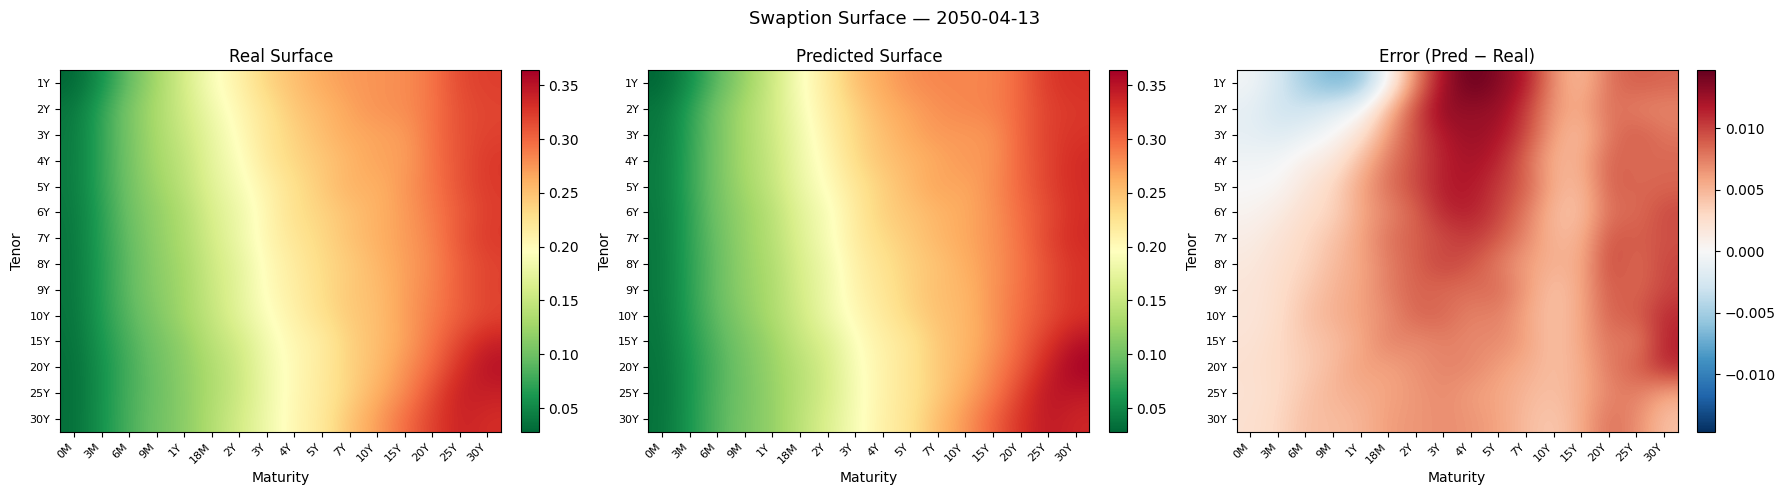

MAE  : 0.006369
Max |error| : 0.014697  at Tenor=1Y, Maturity=4Y


In [85]:
plot_surface_comparison(model, dataset, sample_idx=50)

## Validation Analysis

Metrics are computed separately on the **train set** (460 samples) and the **validation set** (14 days) using direct inference — each prediction uses the real 20-day input window from the dataset, same as during training.

- **MAE**: mean absolute error across all 224 grid cells and all days  
- **RMSE**: root mean squared error (penalises large errors more)  
- **R²**: coefficient of determination (1 = perfect, 0 = mean predictor)  
- **MAPE**: mean absolute percentage error

In [89]:
    
real_tr,  pred_tr  = get_predictions(model, train_ds)
real_val, pred_val = get_predictions(model, val_ds)

print("=" * 75)
print_metrics(real_tr,  pred_tr,  "Model — Train (460 samples)")
print_metrics(real_val, pred_val, "Model — Validation (14 days)")


  Model — Train (460 samples)   MAE=0.00332  RMSE=0.00444  R²=0.9980  MAPE=1.76%
  Model — Validation (14 days)  MAE=0.00407  RMSE=0.00510  R²=0.9972  MAPE=2.87%


## Teacher-Forced vs Autoregressive Inference

Two prediction modes are compared over the 14 validation days.

**Teacher-forced (no autoregression):** every day's input window is built from *real* observed prices. The model never sees its own predictions — this is an optimistic upper bound on performance, since real prices are available at each step.

**Autoregressive:** the model's prediction for day *t* is fed back as input for day *t+1*, replacing the real price. Errors compound over successive steps, reflecting true multi-step forecasting difficulty.

---
### Teacher-Forced

In [57]:
from data.data import TENORS, MATURITIES

TENORS_LIST     = TENORS
MATURITIES_LIST = MATURITIES
N_TEN, N_MAT    = len(TENORS_LIST), len(MATURITIES_LIST)
TRAIN_SPLIT     = 460
CONTEXT_DAYS    = 60   # ← how many training days to show on the left (change freely)

# Pre-compute predictions for ALL samples (train + val) once
all_reals, all_preds, pred_dates = [], [], []
model.eval()
with torch.no_grad():
    for i in range(len(dataset)):
        x, y = dataset[i]
        p = model(x.float().unsqueeze(0)).squeeze(0).numpy()
        all_reals.append(y.numpy())
        all_preds.append(p)
        pred_dates.append(dataset.dates.iloc[i + dataset.lookback])

all_reals  = np.array(all_reals)   # [474, 224]
all_preds  = np.array(all_preds)
split_date = pred_dates[TRAIN_SPLIT]

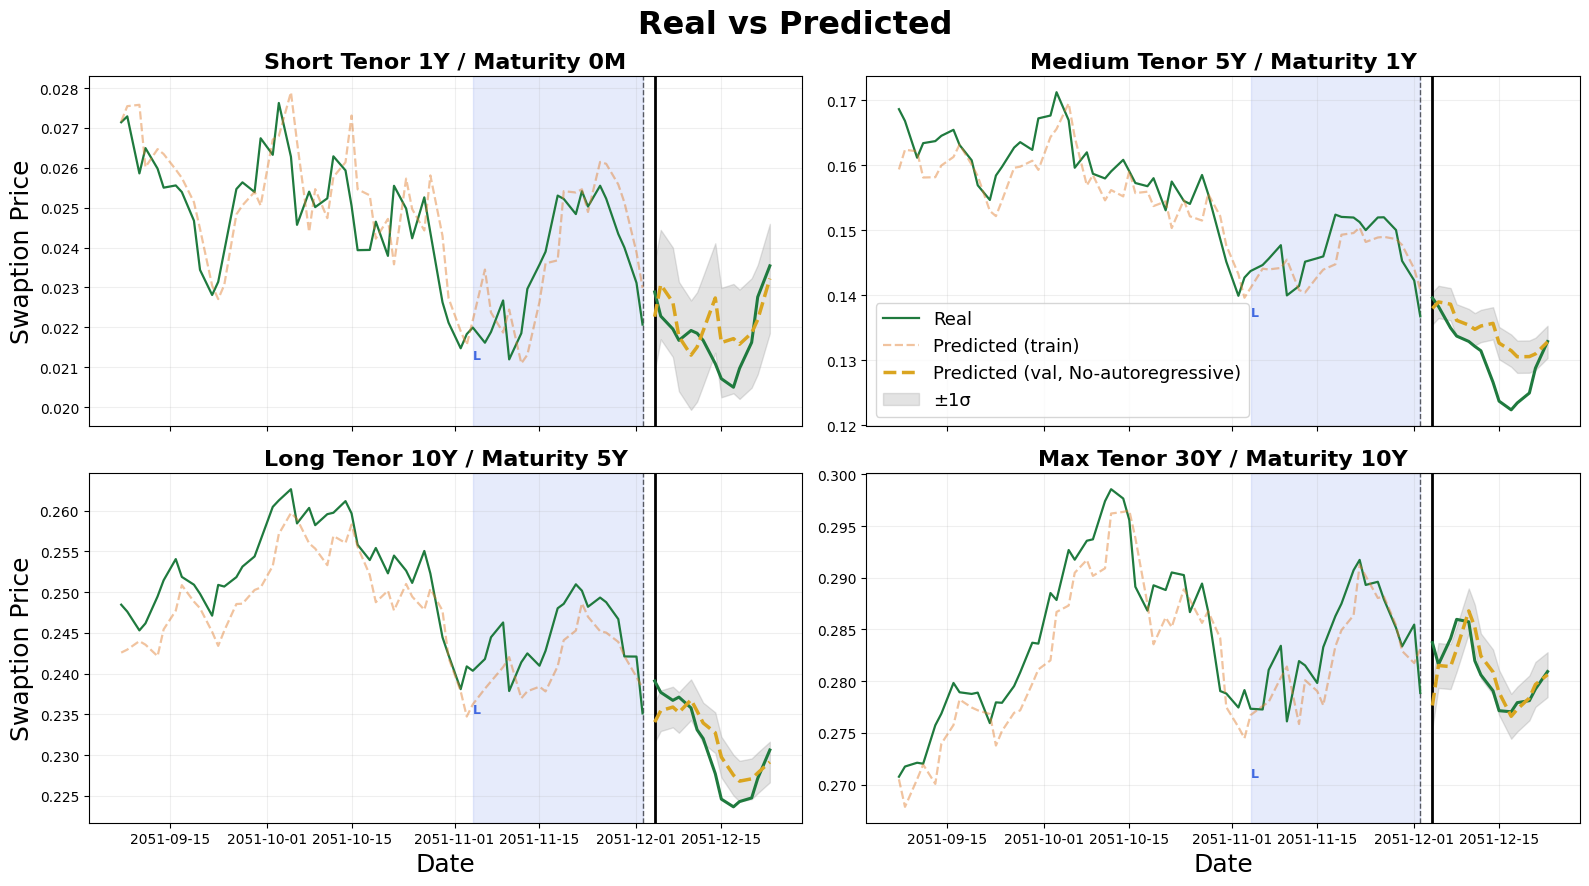

In [60]:
show_start = TRAIN_SPLIT - CONTEXT_DAYS

selected = [
    (1,  0.0833333333333333, "Short Tenor 1Y / Maturity 0M"),
    (5,  1.0,               "Medium Tenor 5Y / Maturity 1Y"),
    (10, 5.0,               "Long Tenor 10Y / Maturity 5Y"),
    (30, 10.0,              "Max Tenor 30Y / Maturity 10Y"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor("white")

for idx, (ax, (tenor, maturity, label)) in enumerate(zip(axes.flatten(), selected)):
    t_idx = TENORS_LIST.index(tenor)
    m_idx = min(range(N_MAT), key=lambda i: abs(MATURITIES_LIST[i] - maturity))
    col   = m_idx * N_TEN + t_idx

    real = all_reals[:, col]
    pred = all_preds[:, col]

    train_std = np.abs(pred[:TRAIN_SPLIT] - real[:TRAIN_SPLIT]).std()

    lb_start = TRAIN_SPLIT - dataset.lookback
    ax.axvspan(pred_dates[lb_start], pred_dates[TRAIN_SPLIT - 1],
               alpha=0.13, color="royalblue", zorder=1)
    ax.annotate("L", xy=(pred_dates[lb_start], real[show_start:TRAIN_SPLIT].min()),
                fontsize=9, color="royalblue", fontweight="bold")
    ax.axvline(pred_dates[TRAIN_SPLIT - 1], color="black", linewidth=1,
               linestyle="--", alpha=0.6)
    ax.axvline(split_date, color="black", linewidth=2)

    ax.plot(pred_dates[show_start:TRAIN_SPLIT], real[show_start:TRAIN_SPLIT],
            color="#1f7a3e", linewidth=1.6, label="Real")
    ax.plot(pred_dates[TRAIN_SPLIT:], real[TRAIN_SPLIT:],
            color="#1f7a3e", linewidth=2.2)
    ax.plot(pred_dates[show_start:TRAIN_SPLIT], pred[show_start:TRAIN_SPLIT],
            color="#e07b2a", linewidth=1.6, linestyle="--", alpha=0.45,
            label="Predicted (train)")
    ax.plot(pred_dates[TRAIN_SPLIT:], pred[TRAIN_SPLIT:],
            color="goldenrod", linewidth=2.5, linestyle="--",
            label="Predicted (val, No-autoregressive)")
    ax.fill_between(pred_dates[TRAIN_SPLIT:],
                    pred[TRAIN_SPLIT:] - train_std,
                    pred[TRAIN_SPLIT:] + train_std,
                    alpha=0.22, color="gray", label="±1σ")

    ax.set_title(label, fontsize=16, fontweight="bold")
    ax.grid(True, alpha=0.2)

    # Solo los plots de la fila inferior tienen etiqueta y ticks del eje x
    if idx < 2:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Date", fontsize=18)
        #ax.tick_params(axis="x", rotation=20)
    
    if idx%2 == 0:
        ax.set_ylabel("Swaption Price", fontsize=18)



axes[0, 1].legend(fontsize=13, loc="lower left")
fig.suptitle("Real vs Predicted", fontsize=23, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/timeseries_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### Autoregressive

- **Day 1**: input = 20 real days (samples 460–479)  
- **Day k**: input = real days shifted by k−1 + the k−1 preceding model predictions  

The time-delta column is always taken from the real dataset (it is a calendar quantity, not a price).

In [ ]:
all_reals, all_preds, pred_dates = [], [], []
model.eval()

with torch.no_grad():
    # ── Días 1..460: predicción directa con ventana real ─────────────────────
    for i in range(TRAIN_SPLIT):
        x, y = dataset[i]
        p = model(x.float().unsqueeze(0)).squeeze(0).numpy()
        all_reals.append(y.numpy())
        all_preds.append(p)
        pred_dates.append(dataset.dates.iloc[i + dataset.lookback])

    # ── Días 461..474: predicción autorregresiva ──────────────────────────────
    # Día 461: ventana = 20 días reales (460..479)
    # Día 462: ventana = 19 días reales (461..479) + predicción del día 461
    # Día 463: ventana = 18 días reales (462..479) + predicciones de 461 y 462
    # ... y así sucesivamente
    n_val_total = len(dataset) - TRAIN_SPLIT
    x_window, _ = dataset[TRAIN_SPLIT]
    x_window = x_window.float().clone()  # ventana inicial: 20 días reales [20, 225]

    for i in range(n_val_total):
        # 1. Predecir con la ventana actual
        p = model(x_window.unsqueeze(0)).squeeze(0).numpy()
        _, y = dataset[TRAIN_SPLIT + i]
        all_reals.append(y.numpy())
        all_preds.append(p)
        pred_dates.append(dataset.dates.iloc[TRAIN_SPLIT + i + dataset.lookback])

        if i < n_val_total - 1:
            # 2. Construir la nueva fila: time_delta real + precios predichos
            x_next, _ = dataset[TRAIN_SPLIT + i + 1]
            new_row = x_next[-1].float().clone()  # [225]: time_delta real, precios reales
            new_row[1:] = torch.tensor(p)          # reemplazar precios con la predicción

            # 3. Avanzar la ventana: quitar el día más antiguo, agregar la nueva fila
            x_window = torch.cat([x_window[1:], new_row.unsqueeze(0)], dim=0)

all_reals  = np.array(all_reals)   # [474, 224]
all_preds  = np.array(all_preds)
split_date = pred_dates[TRAIN_SPLIT]


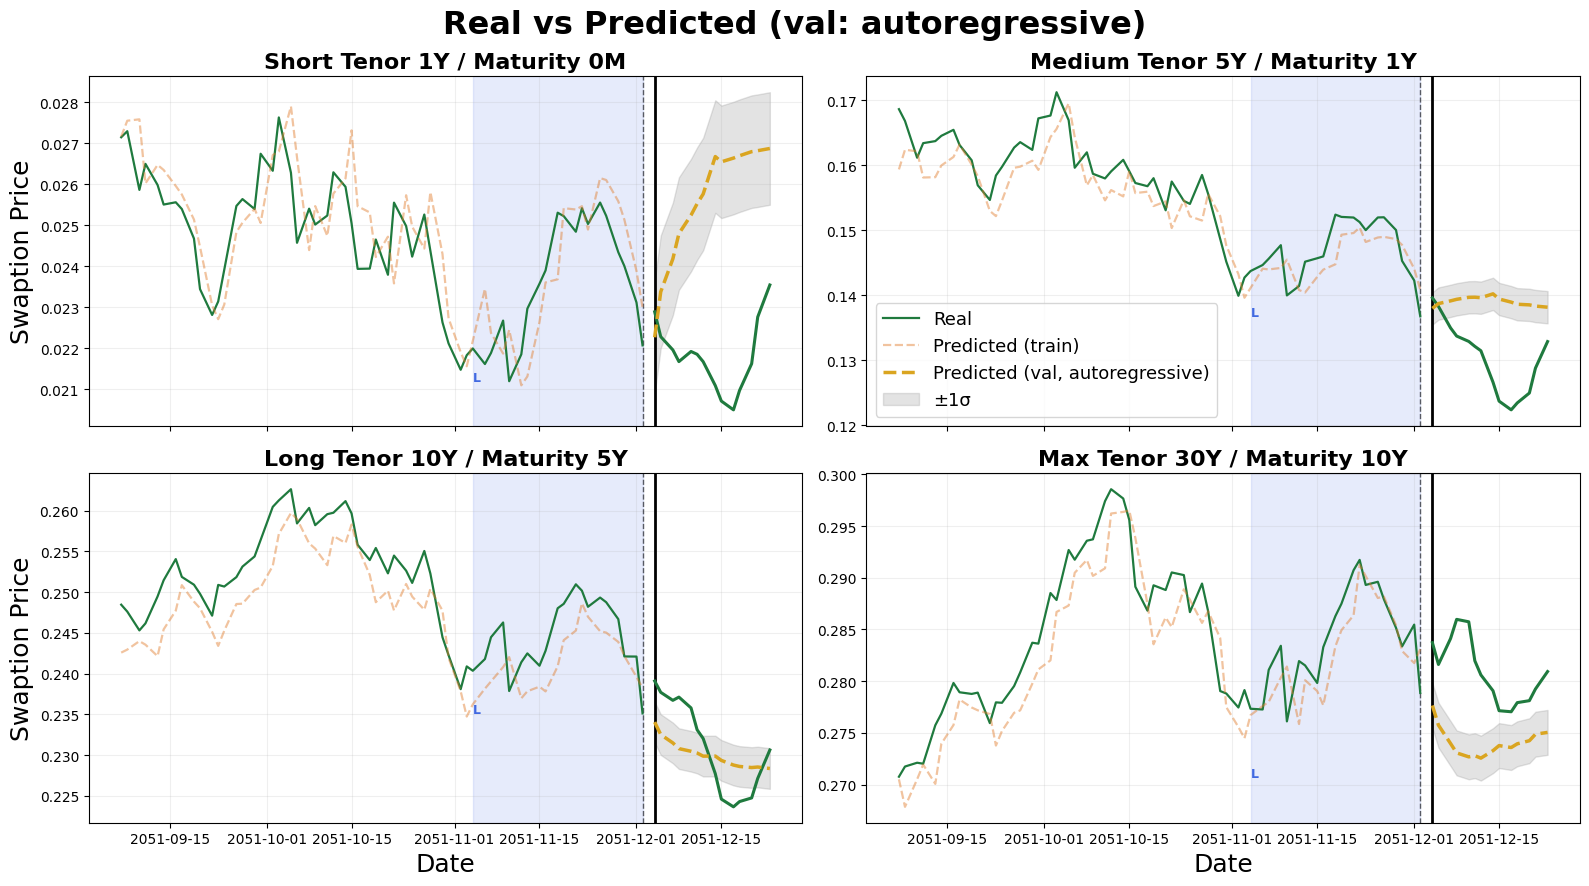

In [56]:
show_start = TRAIN_SPLIT - CONTEXT_DAYS

selected = [
    (1,  0.0833333333333333, "Short Tenor 1Y / Maturity 0M"),
    (5,  1.0,               "Medium Tenor 5Y / Maturity 1Y"),
    (10, 5.0,               "Long Tenor 10Y / Maturity 5Y"),
    (30, 10.0,              "Max Tenor 30Y / Maturity 10Y"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor("white")

for idx, (ax, (tenor, maturity, label)) in enumerate(zip(axes.flatten(), selected)):
    t_idx = TENORS_LIST.index(tenor)
    m_idx = min(range(N_MAT), key=lambda i: abs(MATURITIES_LIST[i] - maturity))
    col   = m_idx * N_TEN + t_idx

    real = all_reals[:, col]
    pred = all_preds[:, col]

    train_std = np.abs(pred[:TRAIN_SPLIT] - real[:TRAIN_SPLIT]).std()

    lb_start = TRAIN_SPLIT - dataset.lookback
    ax.axvspan(pred_dates[lb_start], pred_dates[TRAIN_SPLIT - 1],
               alpha=0.13, color="royalblue", zorder=1)
    ax.annotate("L", xy=(pred_dates[lb_start], real[show_start:TRAIN_SPLIT].min()),
                fontsize=9, color="royalblue", fontweight="bold")
    ax.axvline(pred_dates[TRAIN_SPLIT - 1], color="black", linewidth=1,
               linestyle="--", alpha=0.6)
    ax.axvline(split_date, color="black", linewidth=2)

    ax.plot(pred_dates[show_start:TRAIN_SPLIT], real[show_start:TRAIN_SPLIT],
            color="#1f7a3e", linewidth=1.6, label="Real")
    ax.plot(pred_dates[TRAIN_SPLIT:], real[TRAIN_SPLIT:],
            color="#1f7a3e", linewidth=2.2)
    ax.plot(pred_dates[show_start:TRAIN_SPLIT], pred[show_start:TRAIN_SPLIT],
            color="#e07b2a", linewidth=1.6, linestyle="--", alpha=0.45,
            label="Predicted (train)")
    ax.plot(pred_dates[TRAIN_SPLIT:], pred[TRAIN_SPLIT:],
            color="goldenrod", linewidth=2.5, linestyle="--",
            label="Predicted (val, autoregressive)")
    ax.fill_between(pred_dates[TRAIN_SPLIT:],
                    pred[TRAIN_SPLIT:] - train_std,
                    pred[TRAIN_SPLIT:] + train_std,
                    alpha=0.22, color="gray", label="±1σ")

    ax.set_title(label, fontsize=16, fontweight="bold")
    ax.grid(True, alpha=0.2)

    # Solo los plots de la fila inferior tienen etiqueta y ticks del eje x
    if idx < 2:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Date", fontsize=18)
        #ax.tick_params(axis="x", rotation=20)
    
    if idx%2 == 0:
        ax.set_ylabel("Swaption Price", fontsize=18)



axes[0, 1].legend(fontsize=13, loc="lower left")
fig.suptitle("Real vs Predicted (val: autoregressive)", fontsize=23, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/timeseries_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## Save Model

Saves the trained weights to `model.pth`. The submission requires a `QuantumModel` class (no constructor arguments) whose `state_dict` can be loaded directly:

```python
model = QuantumModel()
model.load_state_dict(torch.load("model.pth"))
```

In [40]:
torch.save(model.state_dict(), "model.pth")
print("Model saved to model.pth")

Model saved to model.pth
